# IE6600 Quiz 7: Seaborn Library

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

# Load dataset
df = pd.read_csv('All_Children_Attendance.csv')
print("Shape:", df.shape)
df.head()

Shape: (1781, 15)


,Title,Date,Month,Fiscal Year,Library,Primary Event Type,Event Type Option 1,Event Type Option 2,Primary Age Group,Age Group Option 1,Age Group Option 2,Description,Internal Notes,Published Status,Attendance
0,Me and You-kelele Storytime,07/01/2016,Jul,FY 17,Noyes Library for Young Children,Storytime,ACE - All Children Excel,NaN,Babies and Toddlers,Preschool and Kindergarten,NaN,"Come Sing, Read, and Rhyme With Us! Stories an...",NaN,Yes,65.0
1,MC Infants & Toddlers Bilingual Storytime,07/01/2016,Jul,FY 17,Gaithersburg,Z_Visits In,Storytime,NaN,Babies and Toddlers,Preschool and Kindergarten,NaN,open bilingual storytime hosted in the library...,NaN,No,90.0
2,lego weekend,07/01/2016,Jul,FY 17,Silver Spring,Science & Math (STEM),ACE - All Children Excel,NaN,Preschool and Kindergarten,Elementary School Age,NaN,friday 2pm- sunday,NaN,No,NaN
3,LEGO Playtime,07/01/2016,Jul,FY 17,Twinbrook,Makerspace,ACE - All Children Excel,Science & Math (STEM),Elementary School Age,Preschool and Kindergarten,NaN,Drop-in for an open session of imaginative con...,NaN,Yes,17.0
4,LEGO Crew,07/01/2016,Jul,FY 17,Gaithersburg,Science & Math (STEM),ACE - All Children Excel,Makerspace,Elementary School Age,Preschool and Kindergarten,NaN,Come showcase your creativity at this free dro...,NaN,Yes,32.0


In [2]:
# Data Preparation
df['Date'] = pd.to_datetime(df['Date'], format='%m/%d/%Y')
df['Year'] = df['Date'].dt.year
df['Month_Num'] = df['Date'].dt.month
df['Description_Length'] = df['Description'].fillna('').apply(len)

# Define month order for plotting
month_order = ['Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec', 'Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun']

print("Data prepared successfully.")
print(f"Attendance - Non-null: {df['Attendance'].notna().sum()}, Null: {df['Attendance'].isna().sum()}")

Data prepared successfully.
Attendance - Non-null: 1412, Null: 369


## Problem 1: Plotting Attendance Distribution

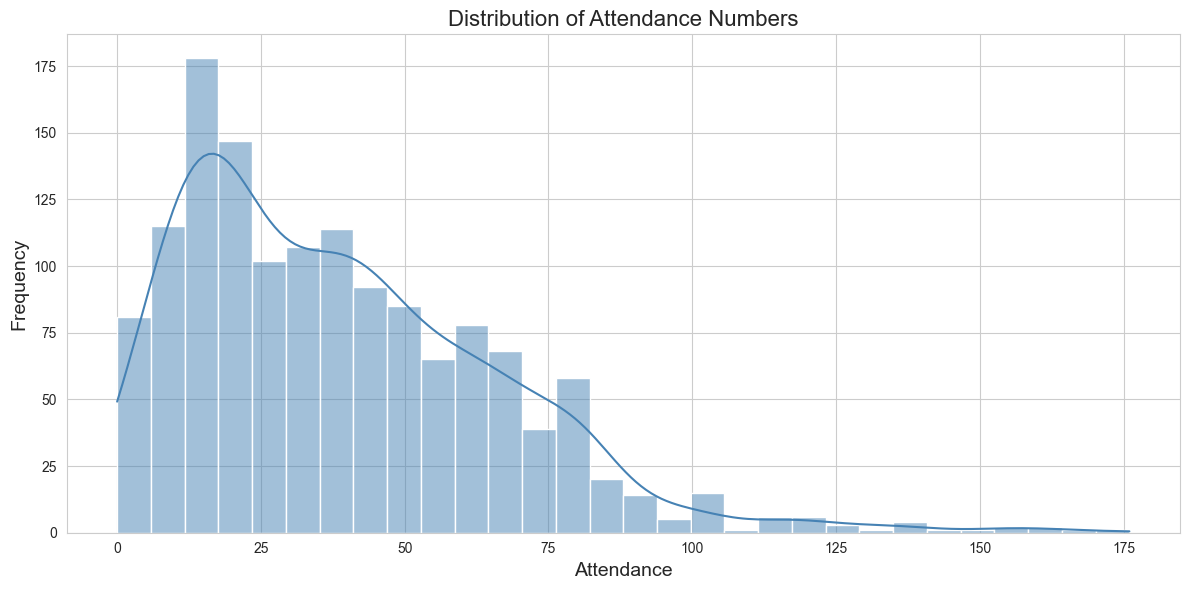

In [3]:
plt.figure(figsize=(12, 6))
sns.histplot(df['Attendance'].dropna(), bins=30, kde=True, color='steelblue')
plt.title('Distribution of Attendance Numbers', fontsize=16)
plt.xlabel('Attendance', fontsize=14)
plt.ylabel('Frequency', fontsize=14)
plt.tight_layout()
plt.show()

## Problem 2: Event Attendance by Library

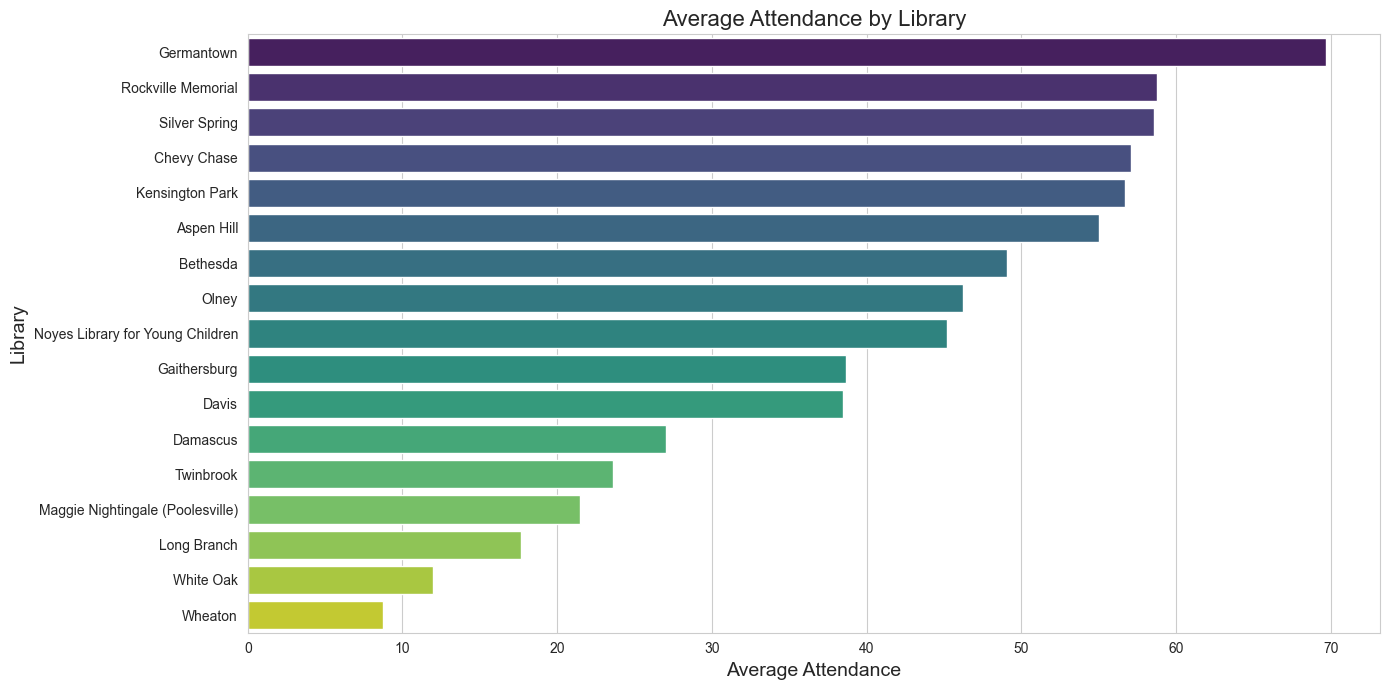

In [4]:
plt.figure(figsize=(14, 7))
library_avg = df.groupby('Library')['Attendance'].mean().sort_values(ascending=False)
sns.barplot(x=library_avg.values, y=library_avg.index, palette='viridis')
plt.title('Average Attendance by Library', fontsize=16)
plt.xlabel('Average Attendance', fontsize=14)
plt.ylabel('Library', fontsize=14)
plt.tight_layout()
plt.show()

## Problem 3: Event Types and Attendance

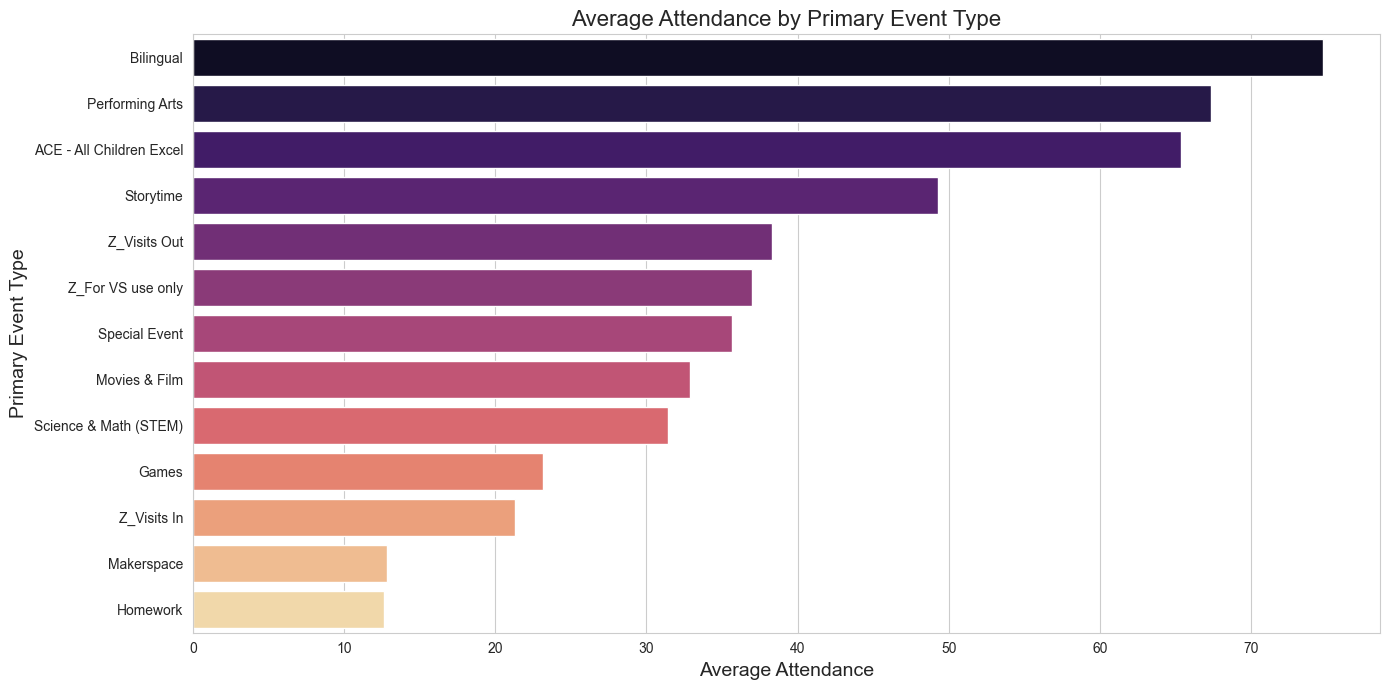

In [5]:
plt.figure(figsize=(14, 7))
event_avg = df.groupby('Primary Event Type')['Attendance'].mean().sort_values(ascending=False)
sns.barplot(x=event_avg.values, y=event_avg.index, palette='magma')
plt.title('Average Attendance by Primary Event Type', fontsize=16)
plt.xlabel('Average Attendance', fontsize=14)
plt.ylabel('Primary Event Type', fontsize=14)
plt.tight_layout()
plt.show()

## Problem 4: Attendance by Month

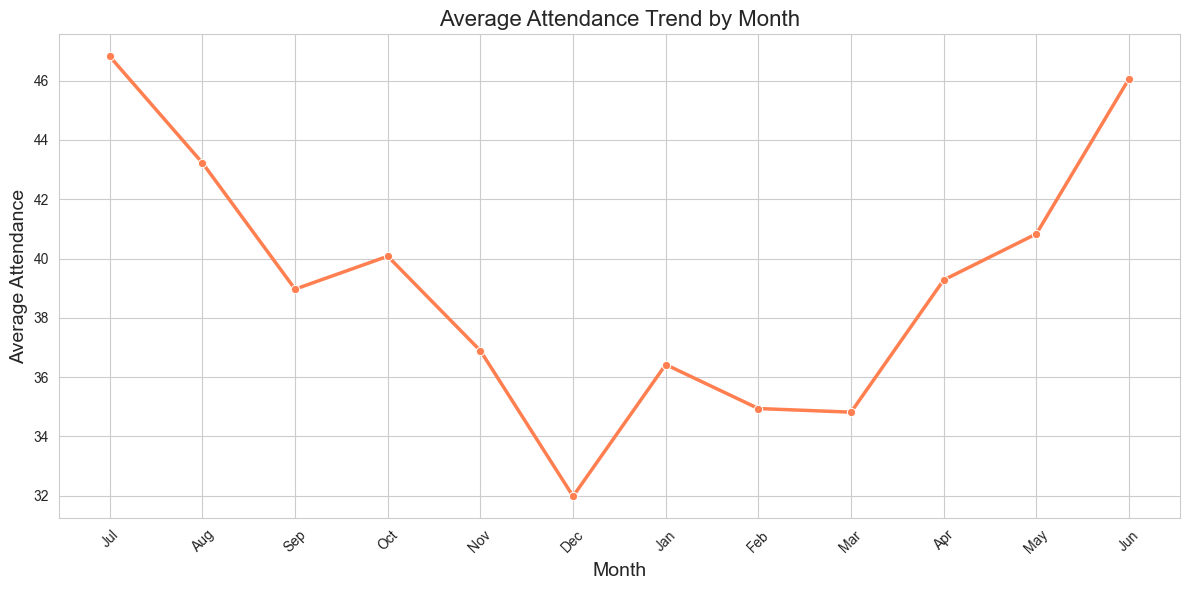

In [6]:
plt.figure(figsize=(12, 6))
monthly_avg = df.groupby('Month')['Attendance'].mean().reindex(month_order)
sns.lineplot(x=monthly_avg.index, y=monthly_avg.values, marker='o', linewidth=2.5, color='coral')
plt.title('Average Attendance Trend by Month', fontsize=16)
plt.xlabel('Month', fontsize=14)
plt.ylabel('Average Attendance', fontsize=14)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Problem 5: Fiscal Year Comparison

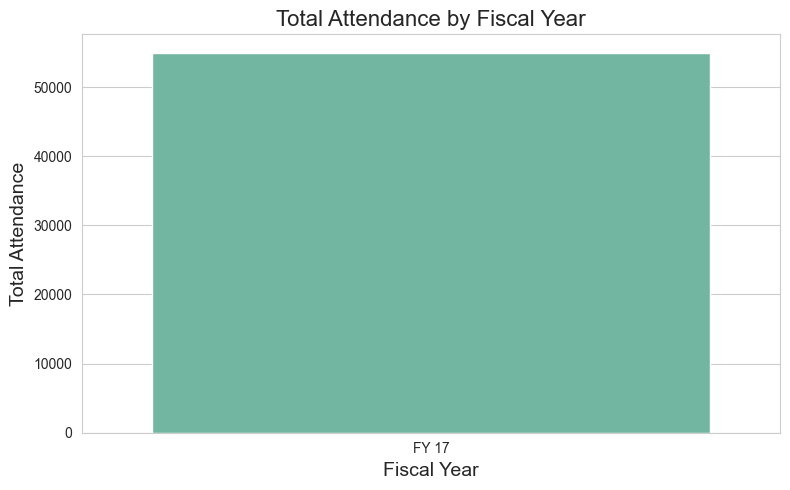

In [7]:
plt.figure(figsize=(8, 5))
fy_total = df.groupby('Fiscal Year')['Attendance'].sum().sort_values(ascending=False)
sns.barplot(x=fy_total.index, y=fy_total.values, palette='Set2')
plt.title('Total Attendance by Fiscal Year', fontsize=16)
plt.xlabel('Fiscal Year', fontsize=14)
plt.ylabel('Total Attendance', fontsize=14)
plt.tight_layout()
plt.show()

## Problem 6: Event Type Options Analysis (Option 1).

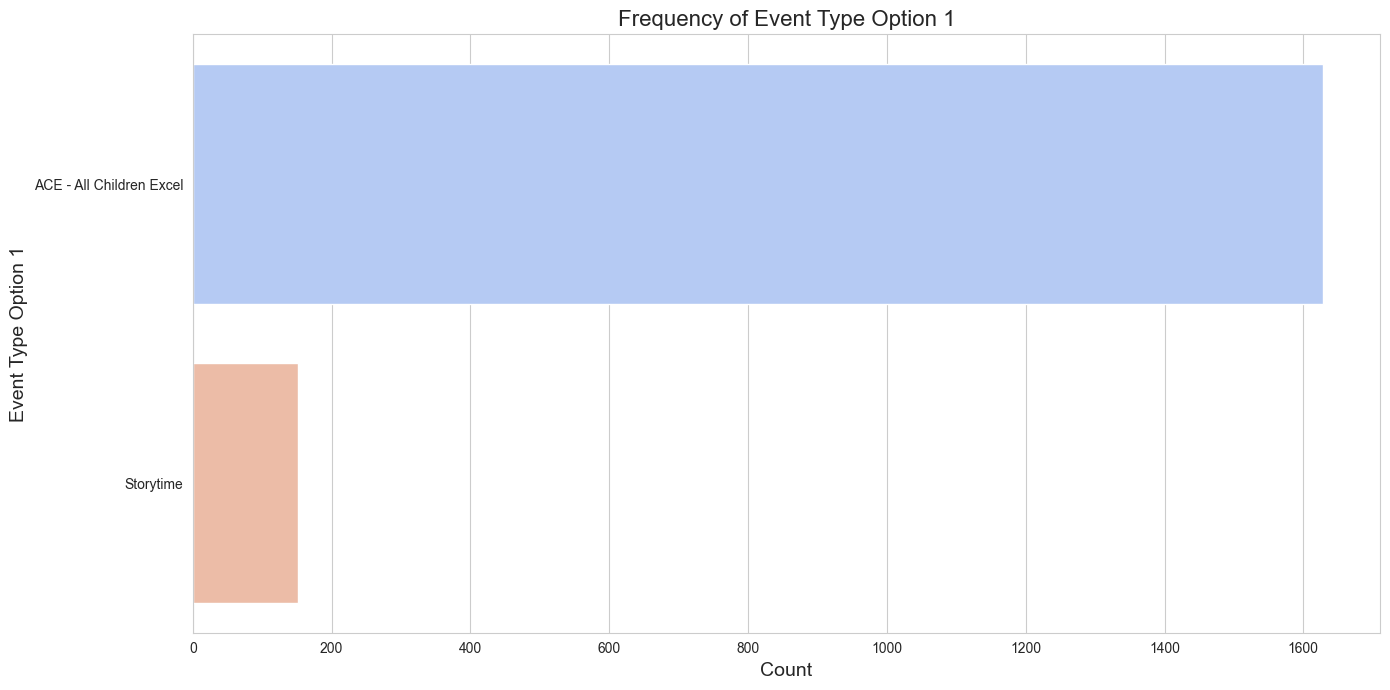

In [8]:
plt.figure(figsize=(14, 7))
option1_counts = df['Event Type Option 1'].value_counts()
sns.countplot(y='Event Type Option 1', data=df, order=option1_counts.index, palette='coolwarm')
plt.title('Frequency of Event Type Option 1', fontsize=16)
plt.xlabel('Count', fontsize=14)
plt.ylabel('Event Type Option 1', fontsize=14)
plt.tight_layout()
plt.show()

## Problem 7: Age Group Analysis

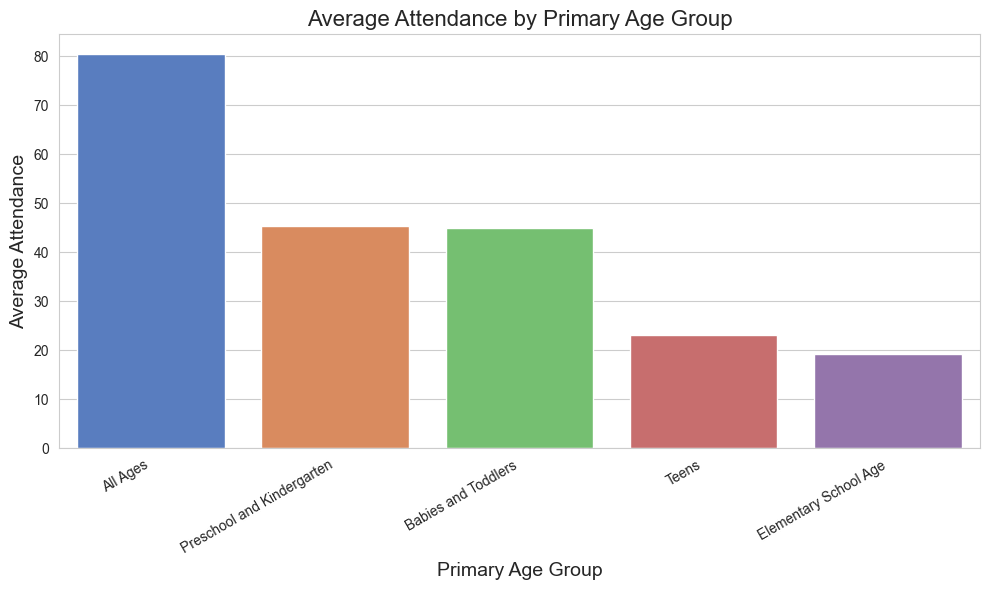

In [9]:
plt.figure(figsize=(10, 6))
age_avg = df.groupby('Primary Age Group')['Attendance'].mean().sort_values(ascending=False)
sns.barplot(x=age_avg.index, y=age_avg.values, palette='muted')
plt.title('Average Attendance by Primary Age Group', fontsize=16)
plt.xlabel('Primary Age Group', fontsize=14)
plt.ylabel('Average Attendance', fontsize=14)
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

## Problem 8: Attendance Distribution by Published Status

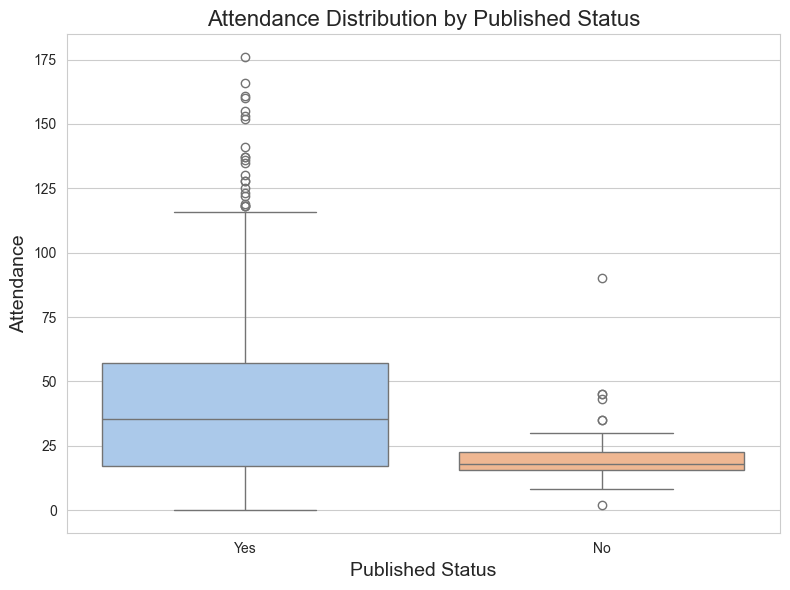

In [10]:
plt.figure(figsize=(8, 6))
sns.boxplot(x='Published Status', y='Attendance', data=df, palette='pastel')
plt.title('Attendance Distribution by Published Status', fontsize=16)
plt.xlabel('Published Status', fontsize=14)
plt.ylabel('Attendance', fontsize=14)
plt.tight_layout()
plt.show()

## Problem 9: Attendance by Event Type Combination

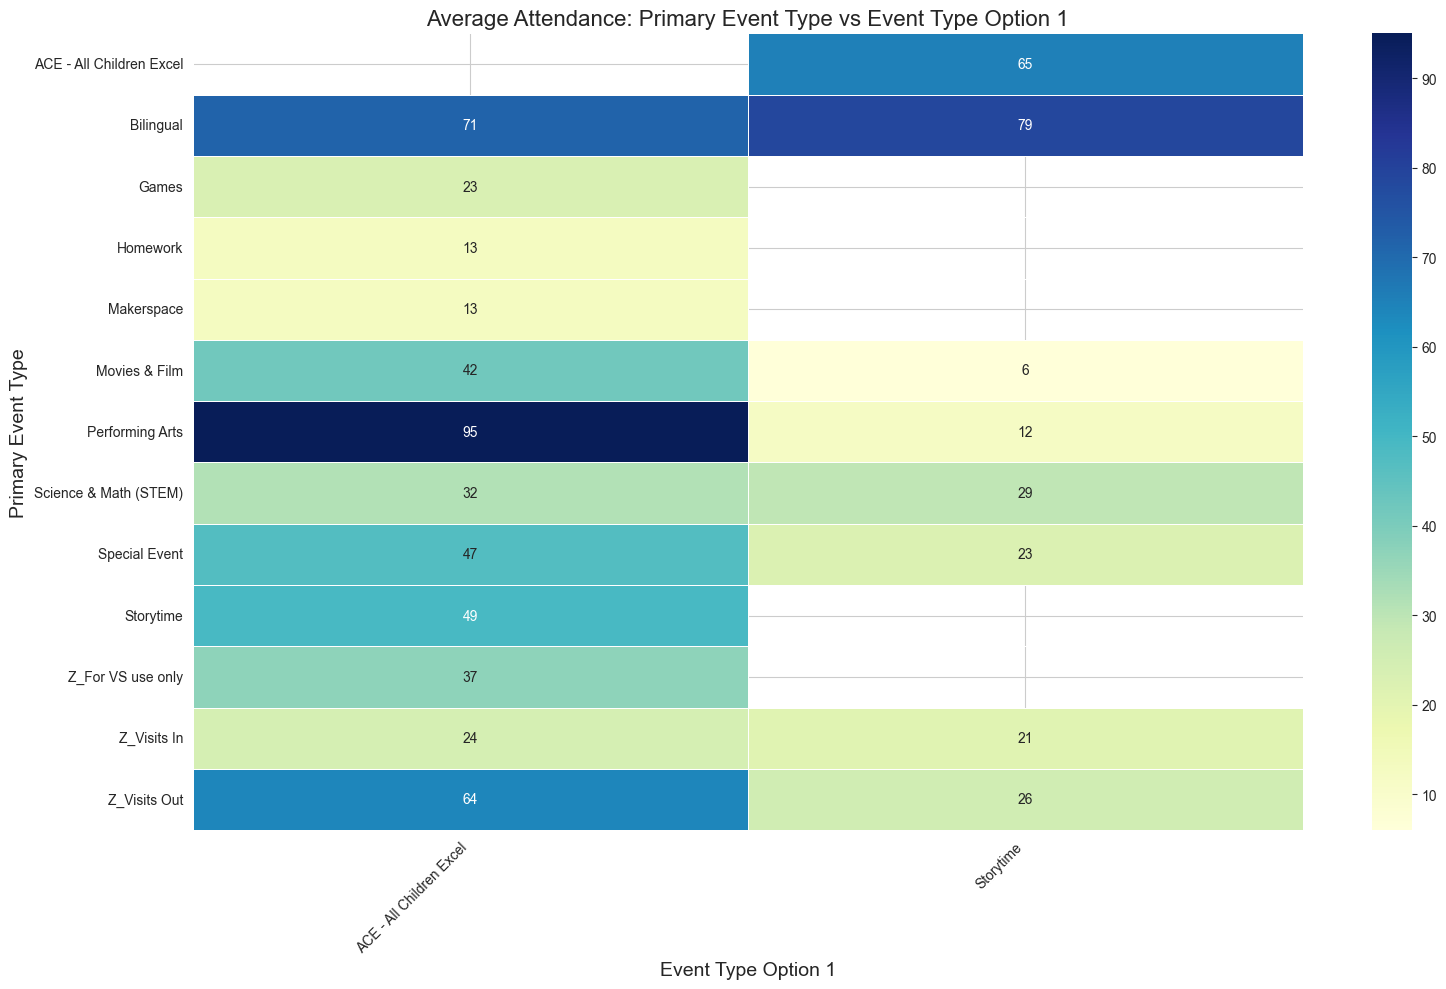

In [11]:
plt.figure(figsize=(16, 10))
pivot_data = df.pivot_table(values='Attendance', index='Primary Event Type', 
                            columns='Event Type Option 1', aggfunc='mean')
sns.heatmap(pivot_data, annot=True, fmt='.0f', cmap='YlGnBu', linewidths=0.5)
plt.title('Average Attendance: Primary Event Type vs Event Type Option 1', fontsize=16)
plt.xlabel('Event Type Option 1', fontsize=14)
plt.ylabel('Primary Event Type', fontsize=14)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## Problem 10: Top Events by Attendance

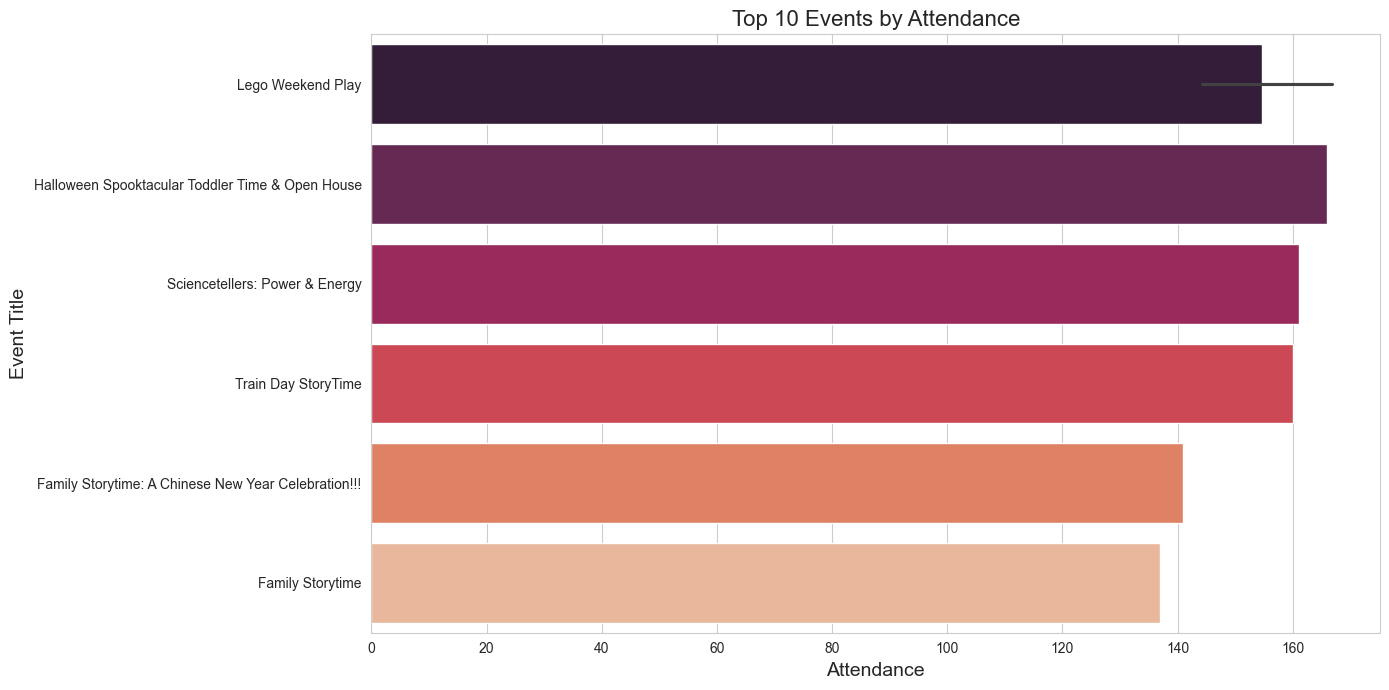

In [12]:
plt.figure(figsize=(14, 7))
top10 = df.nlargest(10, 'Attendance')[['Title', 'Attendance']]
sns.barplot(x='Attendance', y='Title', data=top10, palette='rocket')
plt.title('Top 10 Events by Attendance', fontsize=16)
plt.xlabel('Attendance', fontsize=14)
plt.ylabel('Event Title', fontsize=14)
plt.tight_layout()
plt.show()

## Problem 11: Monthly Attendance Trend by Library

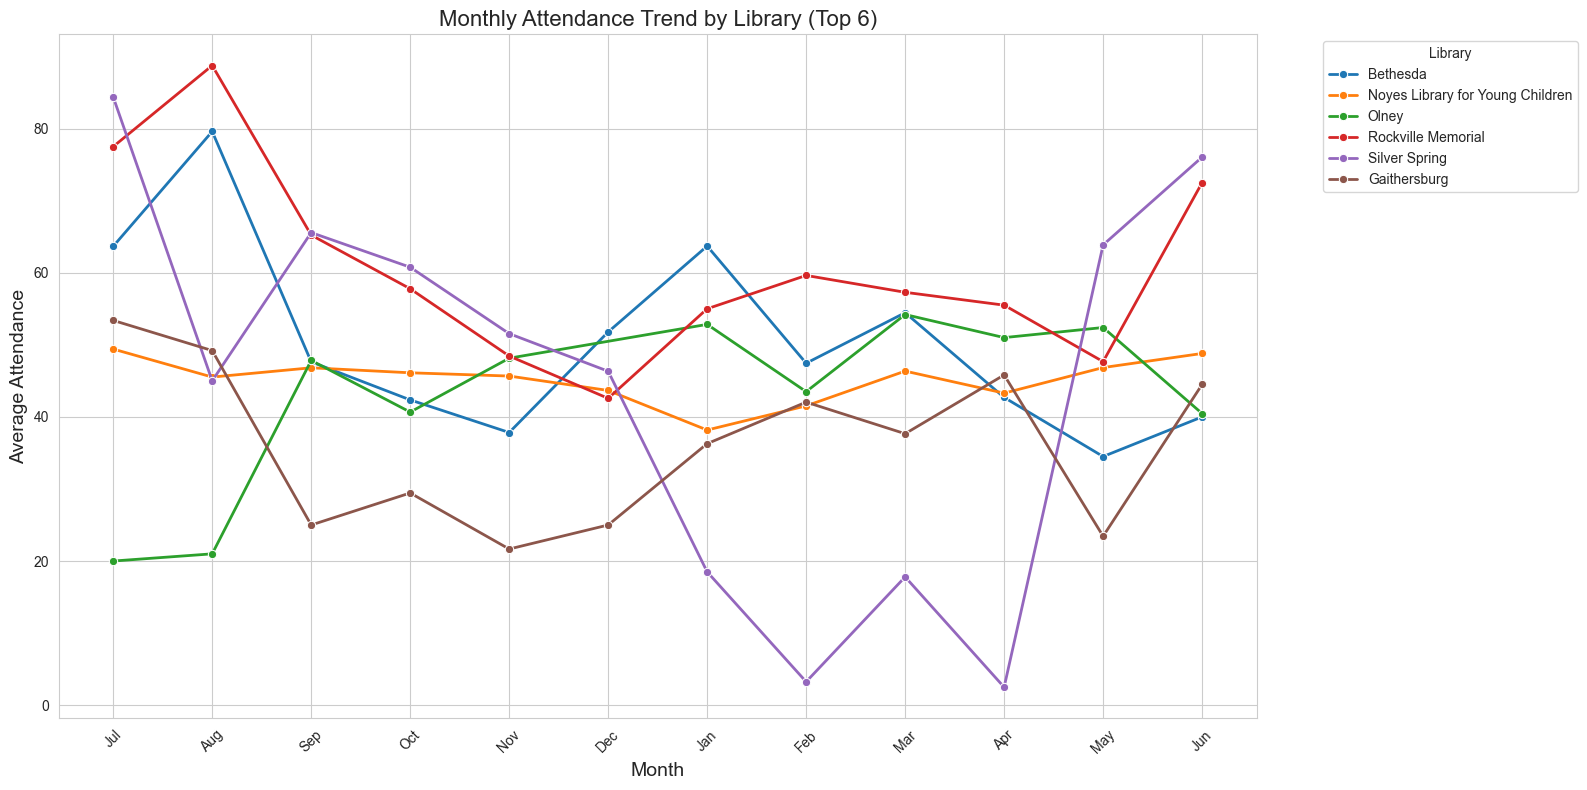

In [13]:
plt.figure(figsize=(16, 8))
top_libraries = df.groupby('Library')['Attendance'].sum().nlargest(6).index
df_top = df[df['Library'].isin(top_libraries)]
monthly_lib = df_top.groupby(['Month', 'Library'])['Attendance'].mean().reset_index()
monthly_lib['Month'] = pd.Categorical(monthly_lib['Month'], categories=month_order, ordered=True)
monthly_lib = monthly_lib.sort_values('Month')

sns.lineplot(data=monthly_lib, x='Month', y='Attendance', hue='Library', marker='o', linewidth=2)
plt.title('Monthly Attendance Trend by Library (Top 6)', fontsize=16)
plt.xlabel('Month', fontsize=14)
plt.ylabel('Average Attendance', fontsize=14)
plt.legend(title='Library', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Problem 12: Attendance by Event Type and Age Group

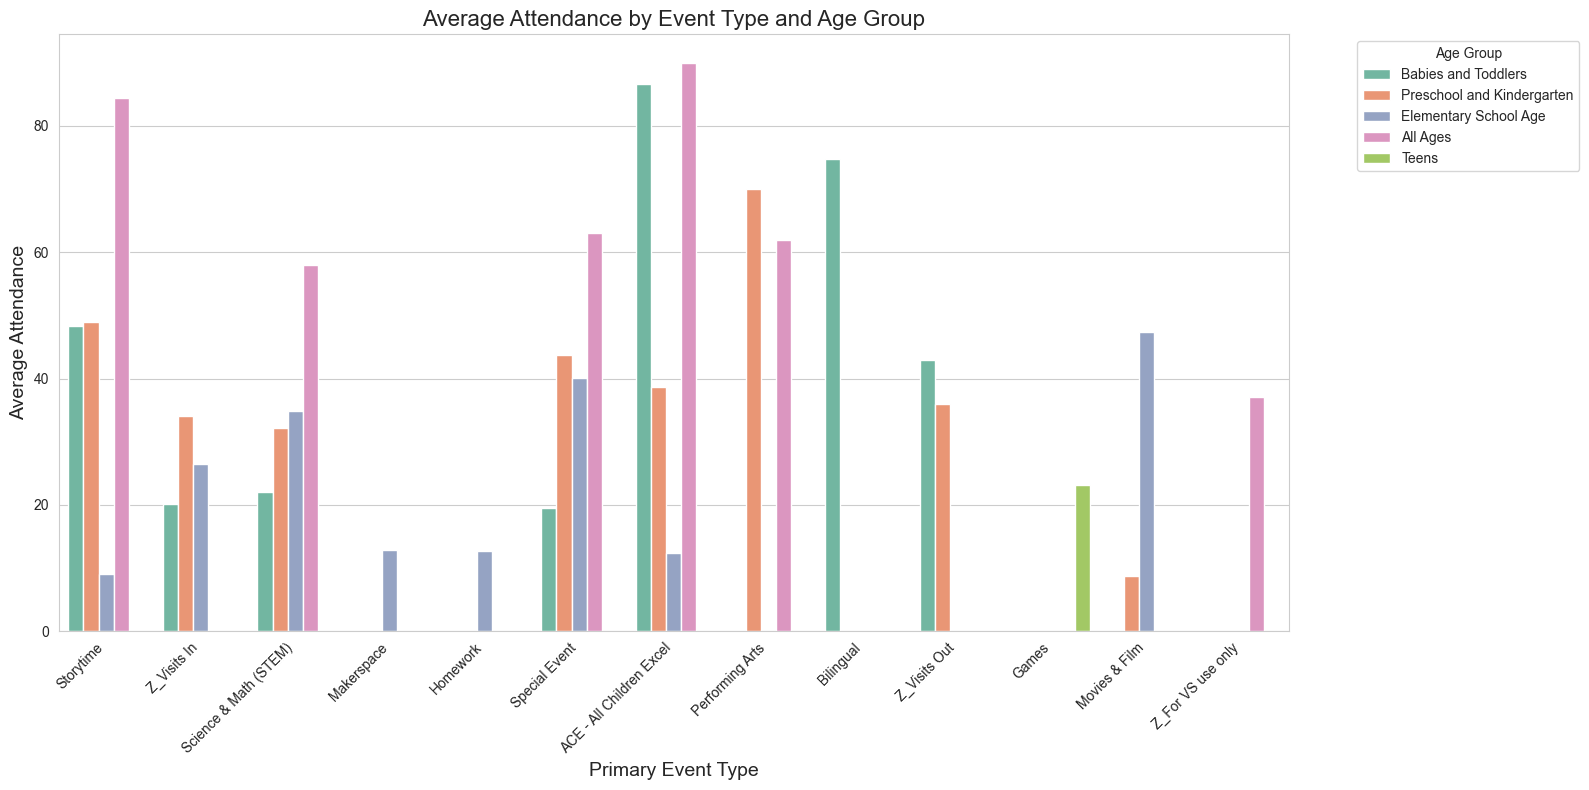

In [14]:
plt.figure(figsize=(16, 8))
sns.barplot(data=df, x='Primary Event Type', y='Attendance', hue='Primary Age Group', 
            palette='Set2', ci=None)
plt.title('Average Attendance by Event Type and Age Group', fontsize=16)
plt.xlabel('Primary Event Type', fontsize=14)
plt.ylabel('Average Attendance', fontsize=14)
plt.xticks(rotation=45, ha='right')
plt.legend(title='Age Group', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

## Problem 13: Attendance Heatmap by Date

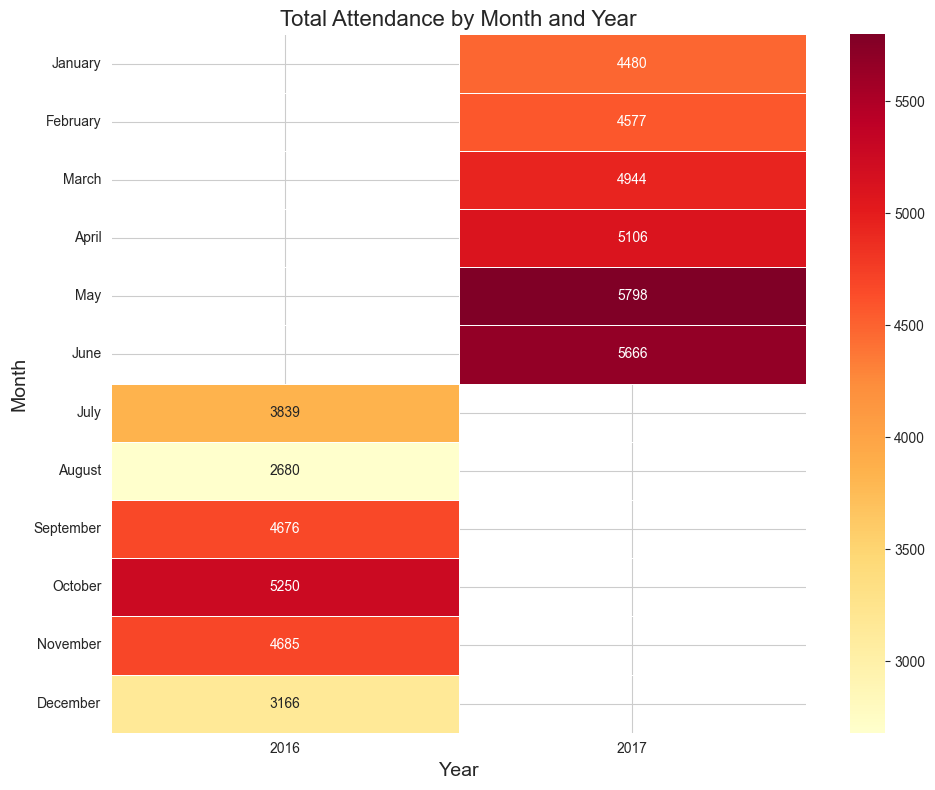

In [15]:
plt.figure(figsize=(10, 8))
df['YearMonth_Year'] = df['Date'].dt.year
df['YearMonth_Month'] = df['Date'].dt.month_name()

month_name_order = ['January', 'February', 'March', 'April', 'May', 'June',
                    'July', 'August', 'September', 'October', 'November', 'December']

pivot_date = df.pivot_table(values='Attendance', index='YearMonth_Month', 
                            columns='YearMonth_Year', aggfunc='sum')
pivot_date = pivot_date.reindex(month_name_order)

sns.heatmap(pivot_date, annot=True, fmt='.0f', cmap='YlOrRd', linewidths=0.5)
plt.title('Total Attendance by Month and Year', fontsize=16)
plt.xlabel('Year', fontsize=14)
plt.ylabel('Month', fontsize=14)
plt.tight_layout()
plt.show()

## Problem 14: Attendance Box Plot by Month

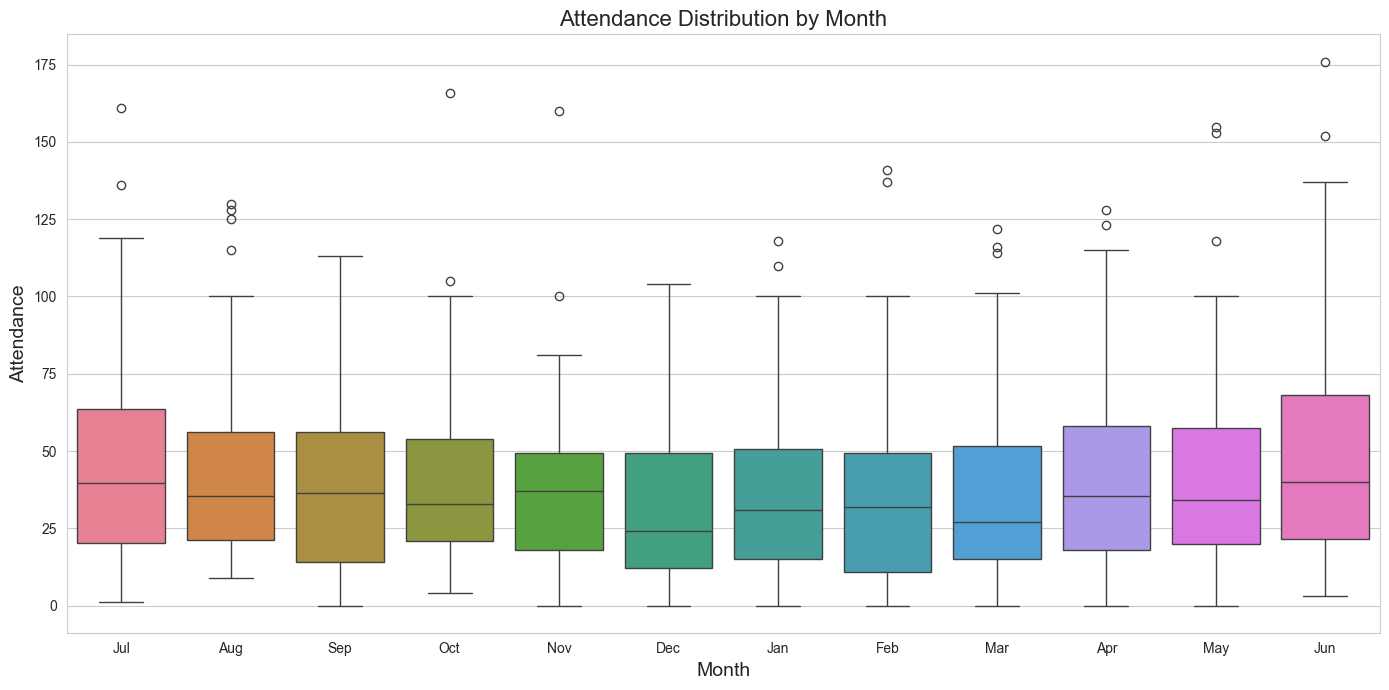

In [16]:
plt.figure(figsize=(14, 7))
df['Month_cat'] = pd.Categorical(df['Month'], categories=month_order, ordered=True)
sns.boxplot(x='Month_cat', y='Attendance', data=df, palette='husl')
plt.title('Attendance Distribution by Month', fontsize=16)
plt.xlabel('Month', fontsize=14)
plt.ylabel('Attendance', fontsize=14)
plt.tight_layout()
plt.show()

## Problem 15: Event Type Option Comparison

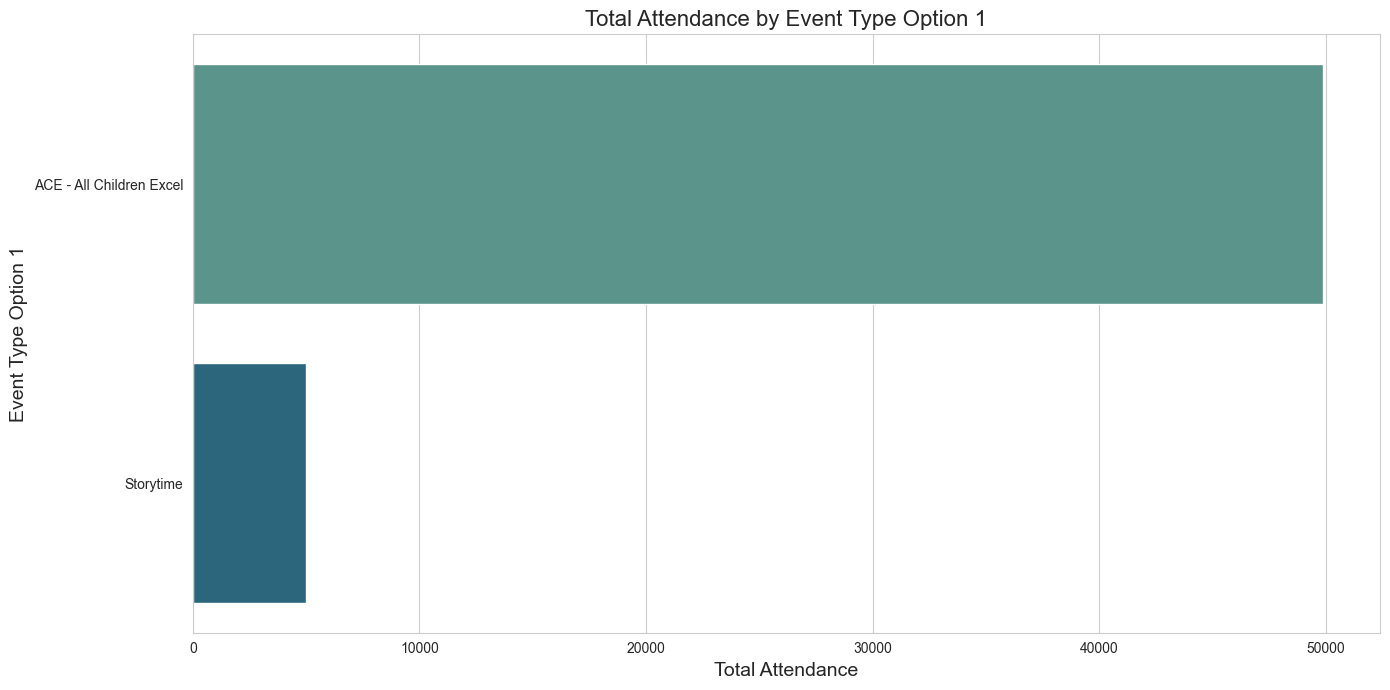

In [17]:
plt.figure(figsize=(14, 7))
option1_total = df.groupby('Event Type Option 1')['Attendance'].sum().sort_values(ascending=False)
sns.barplot(x=option1_total.values, y=option1_total.index, palette='crest')
plt.title('Total Attendance by Event Type Option 1', fontsize=16)
plt.xlabel('Total Attendance', fontsize=14)
plt.ylabel('Event Type Option 1', fontsize=14)
plt.tight_layout()
plt.show()

## Problem 16: Correlation Analysis

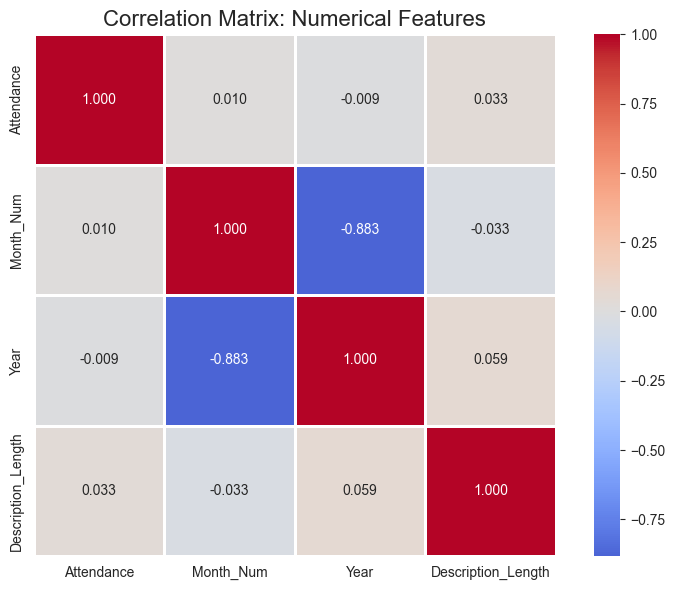

In [18]:
plt.figure(figsize=(8, 6))
numerical_df = df[['Attendance', 'Month_Num', 'Year', 'Description_Length']].dropna()
corr_matrix = numerical_df.corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0, fmt='.3f', 
            linewidths=1, square=True)
plt.title('Correlation Matrix: Numerical Features', fontsize=16)
plt.tight_layout()
plt.show()

## Problem 17: Attendance Distribution by Description Length

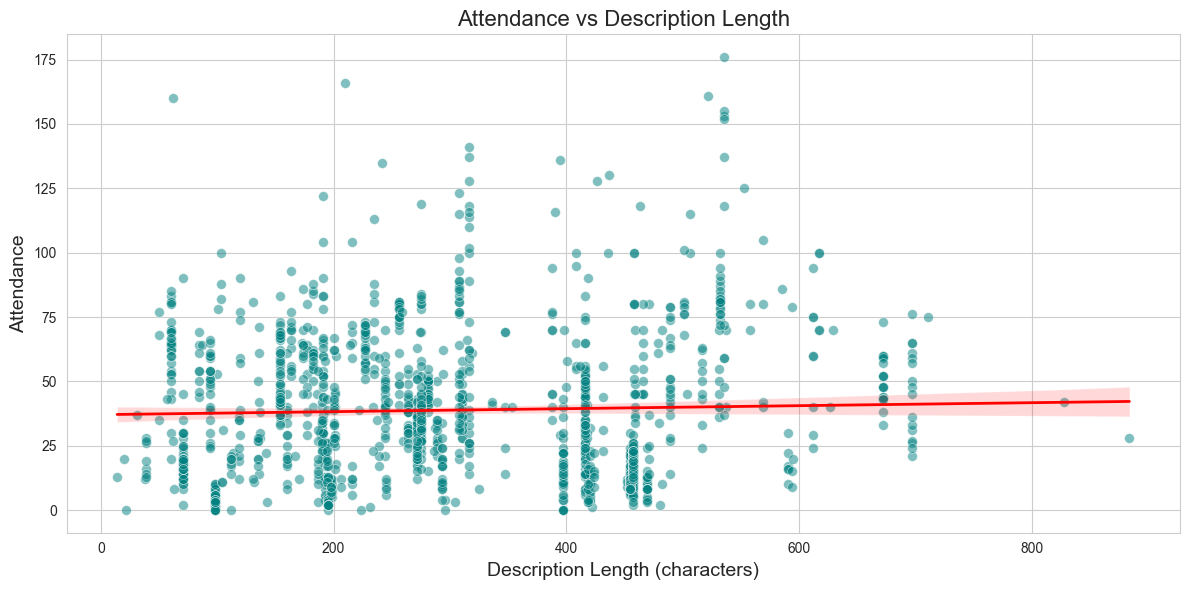

In [19]:
plt.figure(figsize=(12, 6))
df_scatter = df.dropna(subset=['Attendance'])
sns.scatterplot(x='Description_Length', y='Attendance', data=df_scatter, 
                alpha=0.5, color='teal', edgecolor='white', s=50)
sns.regplot(x='Description_Length', y='Attendance', data=df_scatter, 
            scatter=False, color='red', line_kws={'linewidth': 2})
plt.title('Attendance vs Description Length', fontsize=16)
plt.xlabel('Description Length (characters)', fontsize=14)
plt.ylabel('Attendance', fontsize=14)
plt.tight_layout()
plt.show()

## Problem 18: Trend Analysis by Age Group

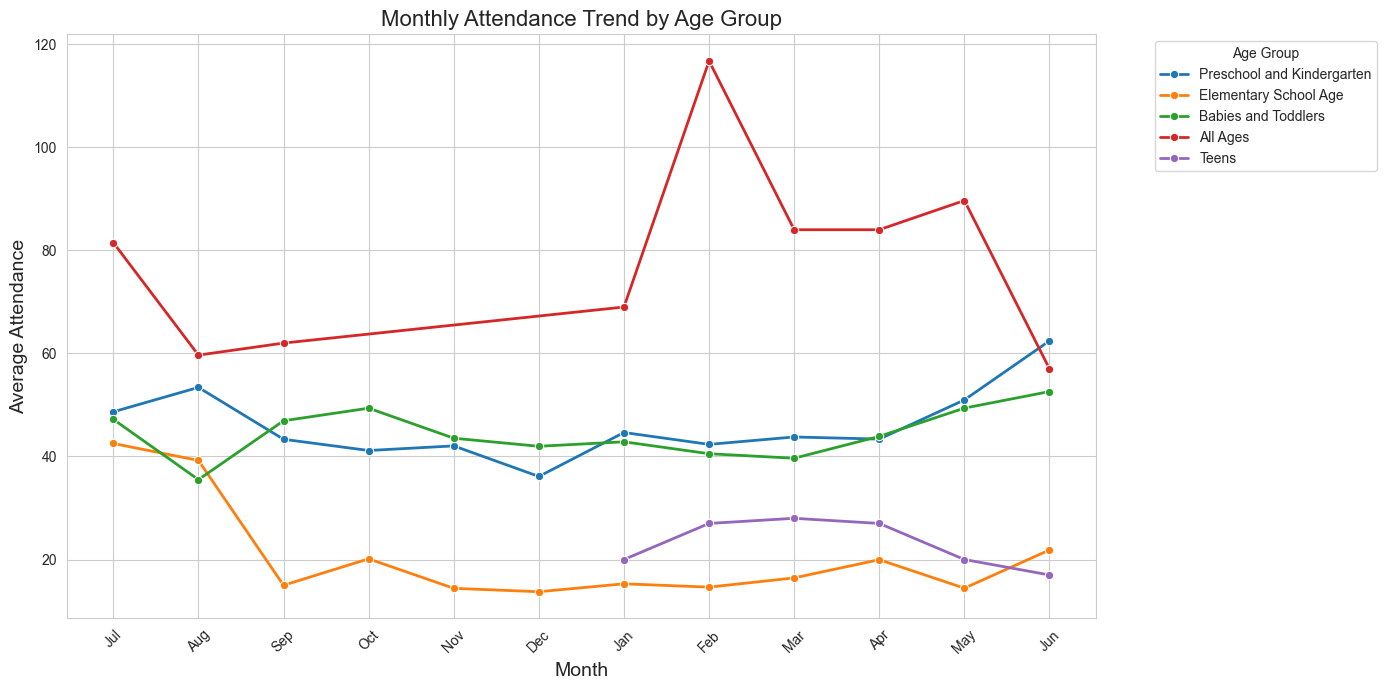

In [20]:
plt.figure(figsize=(14, 7))
age_monthly = df.groupby(['Month', 'Primary Age Group'])['Attendance'].mean().reset_index()
age_monthly['Month'] = pd.Categorical(age_monthly['Month'], categories=month_order, ordered=True)
age_monthly = age_monthly.sort_values('Month')

sns.lineplot(data=age_monthly, x='Month', y='Attendance', hue='Primary Age Group', 
             marker='o', linewidth=2, palette='tab10')
plt.title('Monthly Attendance Trend by Age Group', fontsize=16)
plt.xlabel('Month', fontsize=14)
plt.ylabel('Average Attendance', fontsize=14)
plt.legend(title='Age Group', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Problem 19: Library Event Frequency

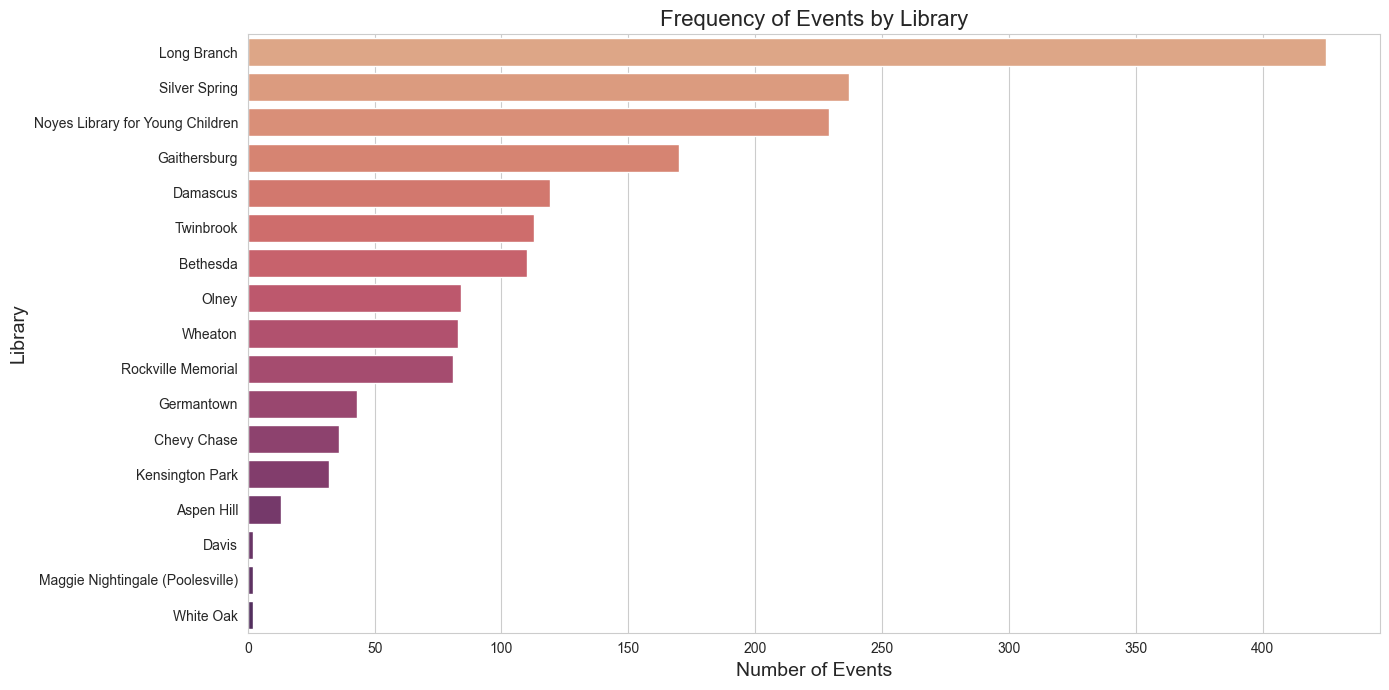

In [21]:
plt.figure(figsize=(14, 7))
lib_counts = df['Library'].value_counts()
sns.barplot(x=lib_counts.values, y=lib_counts.index, palette='flare')
plt.title('Frequency of Events by Library', fontsize=16)
plt.xlabel('Number of Events', fontsize=14)
plt.ylabel('Library', fontsize=14)
plt.tight_layout()
plt.show()

## Problem 20: Impact of Event Description on Attendance

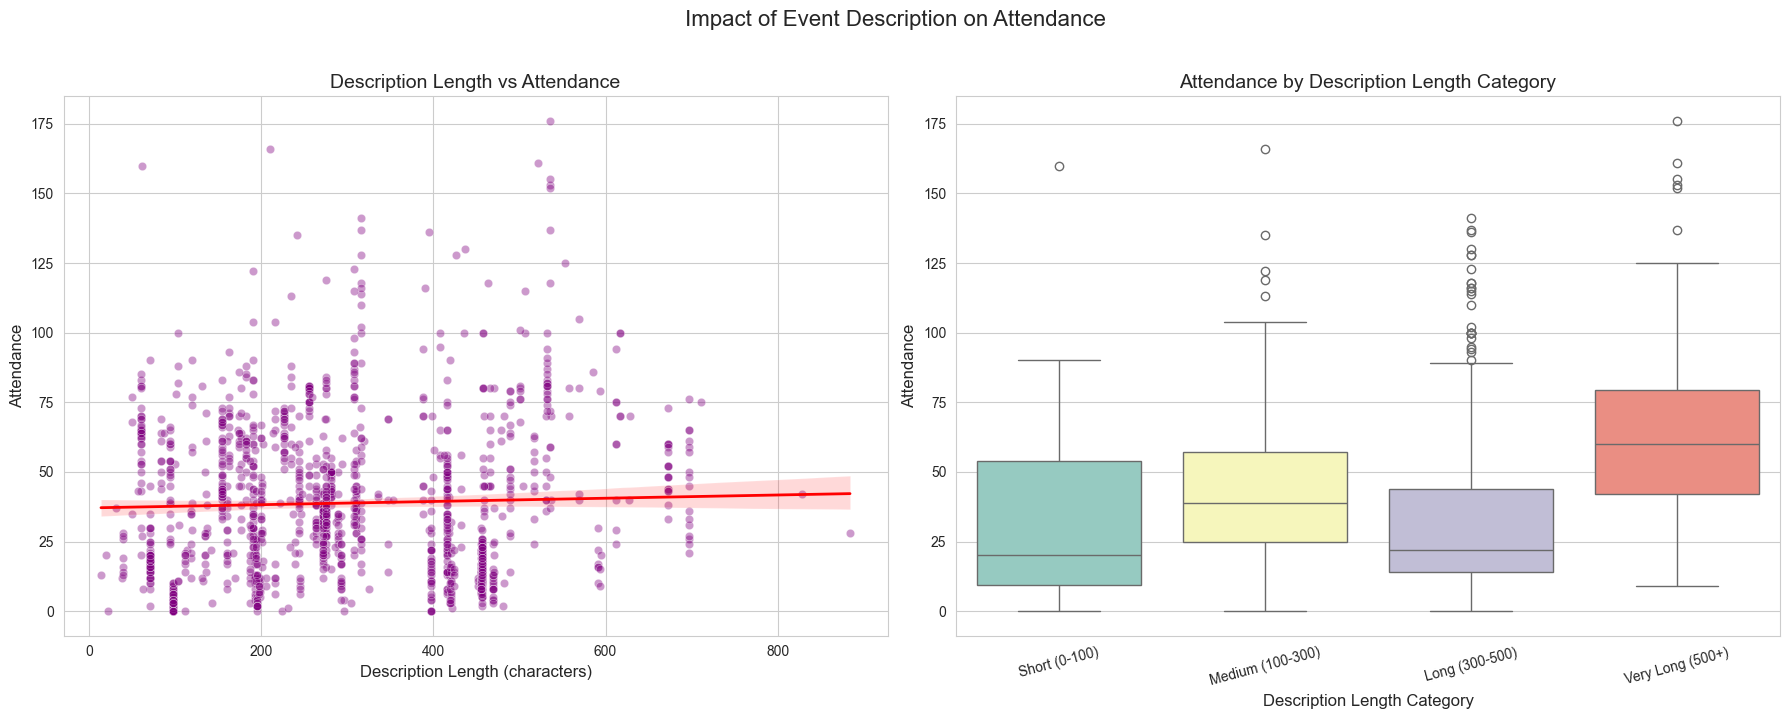


Correlation between Description Length and Attendance: 0.0331
Interpretation: Weak positive correlation.


In [22]:
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Scatter plot
df_valid = df.dropna(subset=['Attendance'])
sns.scatterplot(x='Description_Length', y='Attendance', data=df_valid, 
                alpha=0.4, color='purple', ax=axes[0])
sns.regplot(x='Description_Length', y='Attendance', data=df_valid, 
            scatter=False, color='red', ax=axes[0], line_kws={'linewidth': 2})
axes[0].set_title('Description Length vs Attendance', fontsize=14)
axes[0].set_xlabel('Description Length (characters)', fontsize=12)
axes[0].set_ylabel('Attendance', fontsize=12)

# Bin descriptions into categories and compare
df_valid['Desc_Category'] = pd.cut(df_valid['Description_Length'], 
                                    bins=[0, 100, 300, 500, df_valid['Description_Length'].max()],
                                    labels=['Short (0-100)', 'Medium (100-300)', 
                                            'Long (300-500)', 'Very Long (500+)'])
sns.boxplot(x='Desc_Category', y='Attendance', data=df_valid, palette='Set3', ax=axes[1])
axes[1].set_title('Attendance by Description Length Category', fontsize=14)
axes[1].set_xlabel('Description Length Category', fontsize=12)
axes[1].set_ylabel('Attendance', fontsize=12)
axes[1].tick_params(axis='x', rotation=15)

plt.suptitle('Impact of Event Description on Attendance', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

# Print correlation
corr = df_valid[['Description_Length', 'Attendance']].corr().iloc[0, 1]
print(f"\nCorrelation between Description Length and Attendance: {corr:.4f}")
print("Interpretation: " + ("Weak" if abs(corr) < 0.3 else "Moderate" if abs(corr) < 0.7 else "Strong") + 
      f" {'positive' if corr > 0 else 'negative'} correlation.")